# **EXERCISE 3 - XGBoost**

**Group 2607**
* Daniele Ghezzi 2195461 (daniele.ghezzi@studenti.unipd.it)
* Fabio Cimino 2197528 (fabio.cimino@studenti.unipd.it)
* Riccardo Ferrante 2196576 (riccardo.ferrante@studenti.unipd.it)
* Federico Scianna 2183435 (federico.scianna@studenti.unipd.it)


Study the data in the file x_XGB_26.dat (N=5000 samples) with labels y_XGB_26.dat. The dataset should be split into N’ training samples and N’’ validation samples, with N’+N’’=N.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting 
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

# Read and split data
np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_test,y_test = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

XGBoost version: 2.1.4
N=5000, N_train=3750, L=4


## 1. Model complexity, parameters and regularization
Try different parameters (λ, γ, n_estimators, …). Which is the simplest yet effective XGB model that keeps a good validation accuracy? Is regularization useful for this analysis?

We perform a grid search over the hyperparameters γ, n_estimators, learning_rate, and max_depth. We then repeat the search including the hyperparameter λ in order to evaluate the usefulness of regularization for this analysis.

In [3]:
from sklearn.model_selection import GridSearchCV


xgb_classifier = XGBClassifier(seed=1, objective='binary:logistic')

grid_search_no_reg = GridSearchCV(estimator=xgb_classifier,
                           cv = 4, # use cross validation with 4 folds
                           param_grid={
                               "gamma": [0.005, 0.01, 0.02, 0.04], #0.001
                               "n_estimators": [50, 100, 150, 200],
                               "learning_rate": [0.02, 0.04, 0.06, 0.08],
                                "max_depth": [10, 20, 30, 40] # 15, 25
                           })

grid_search_no_reg.fit(x_train, y_train)

best_params_no_reg = grid_search_no_reg.best_params_

print("Best hyperparameters (no regularization): ", best_params_no_reg)
print(f"Best validation score (no regularization): {grid_search_no_reg.best_score_}")

grid_search = GridSearchCV(estimator=xgb_classifier,
                           cv = 4, # use cross validation with 4 folds
                           param_grid={
                               "gamma": [0.01, 0.02, 0.04],
                               "n_estimators": [100, 150, 200],
                               "learning_rate": [0.04, 0.06, 0.08],
                                "max_depth": [20, 30, 40],
                                "lambda": [0.01, 0.1, 1.0, 10.0, 100.0]
                           })

grid_search.fit(x_train, y_train)

best_params = grid_search.best_params_

print("Best hyperparameters (with regularization): ", best_params)
print(f"Best validation score (with regularization): {grid_search.best_score_}")

Best hyperparameters (no regularization):  {'gamma': 0.02, 'learning_rate': 0.06, 'max_depth': 30, 'n_estimators': 150}
Best validation score (no regularization): 0.932533456365072
Best hyperparameters (with regularization):  {'gamma': 0.02, 'lambda': 1.0, 'learning_rate': 0.06, 'max_depth': 30, 'n_estimators': 150}
Best validation score (with regularization): 0.932533456365072


We see that regularization does not improve the validation score, so we keep the best model without it. We compute its test accuracy:

In [4]:
best_classifier = XGBClassifier(seed=1, objective='binary:logistic', **best_params_no_reg)
best_classifier.fit(x_train, y_train)
best_accuracy = best_classifier.score(x_test, y_test)
print("Best hyperparameters (no regularization): ", best_params_no_reg)
print(f"Best test accuracy: ", best_accuracy)

Best hyperparameters (no regularization):  {'gamma': 0.02, 'learning_rate': 0.06, 'max_depth': 30, 'n_estimators': 150}
Best test accuracy:  0.9392


## 2. Dimensionality reduction
Consider reduced data samples with L’<L features. For example, feature 0,1, and 3 out of the L=4 features. Check if the exclusion of the least important feature(s) from training data leads to better accuracy

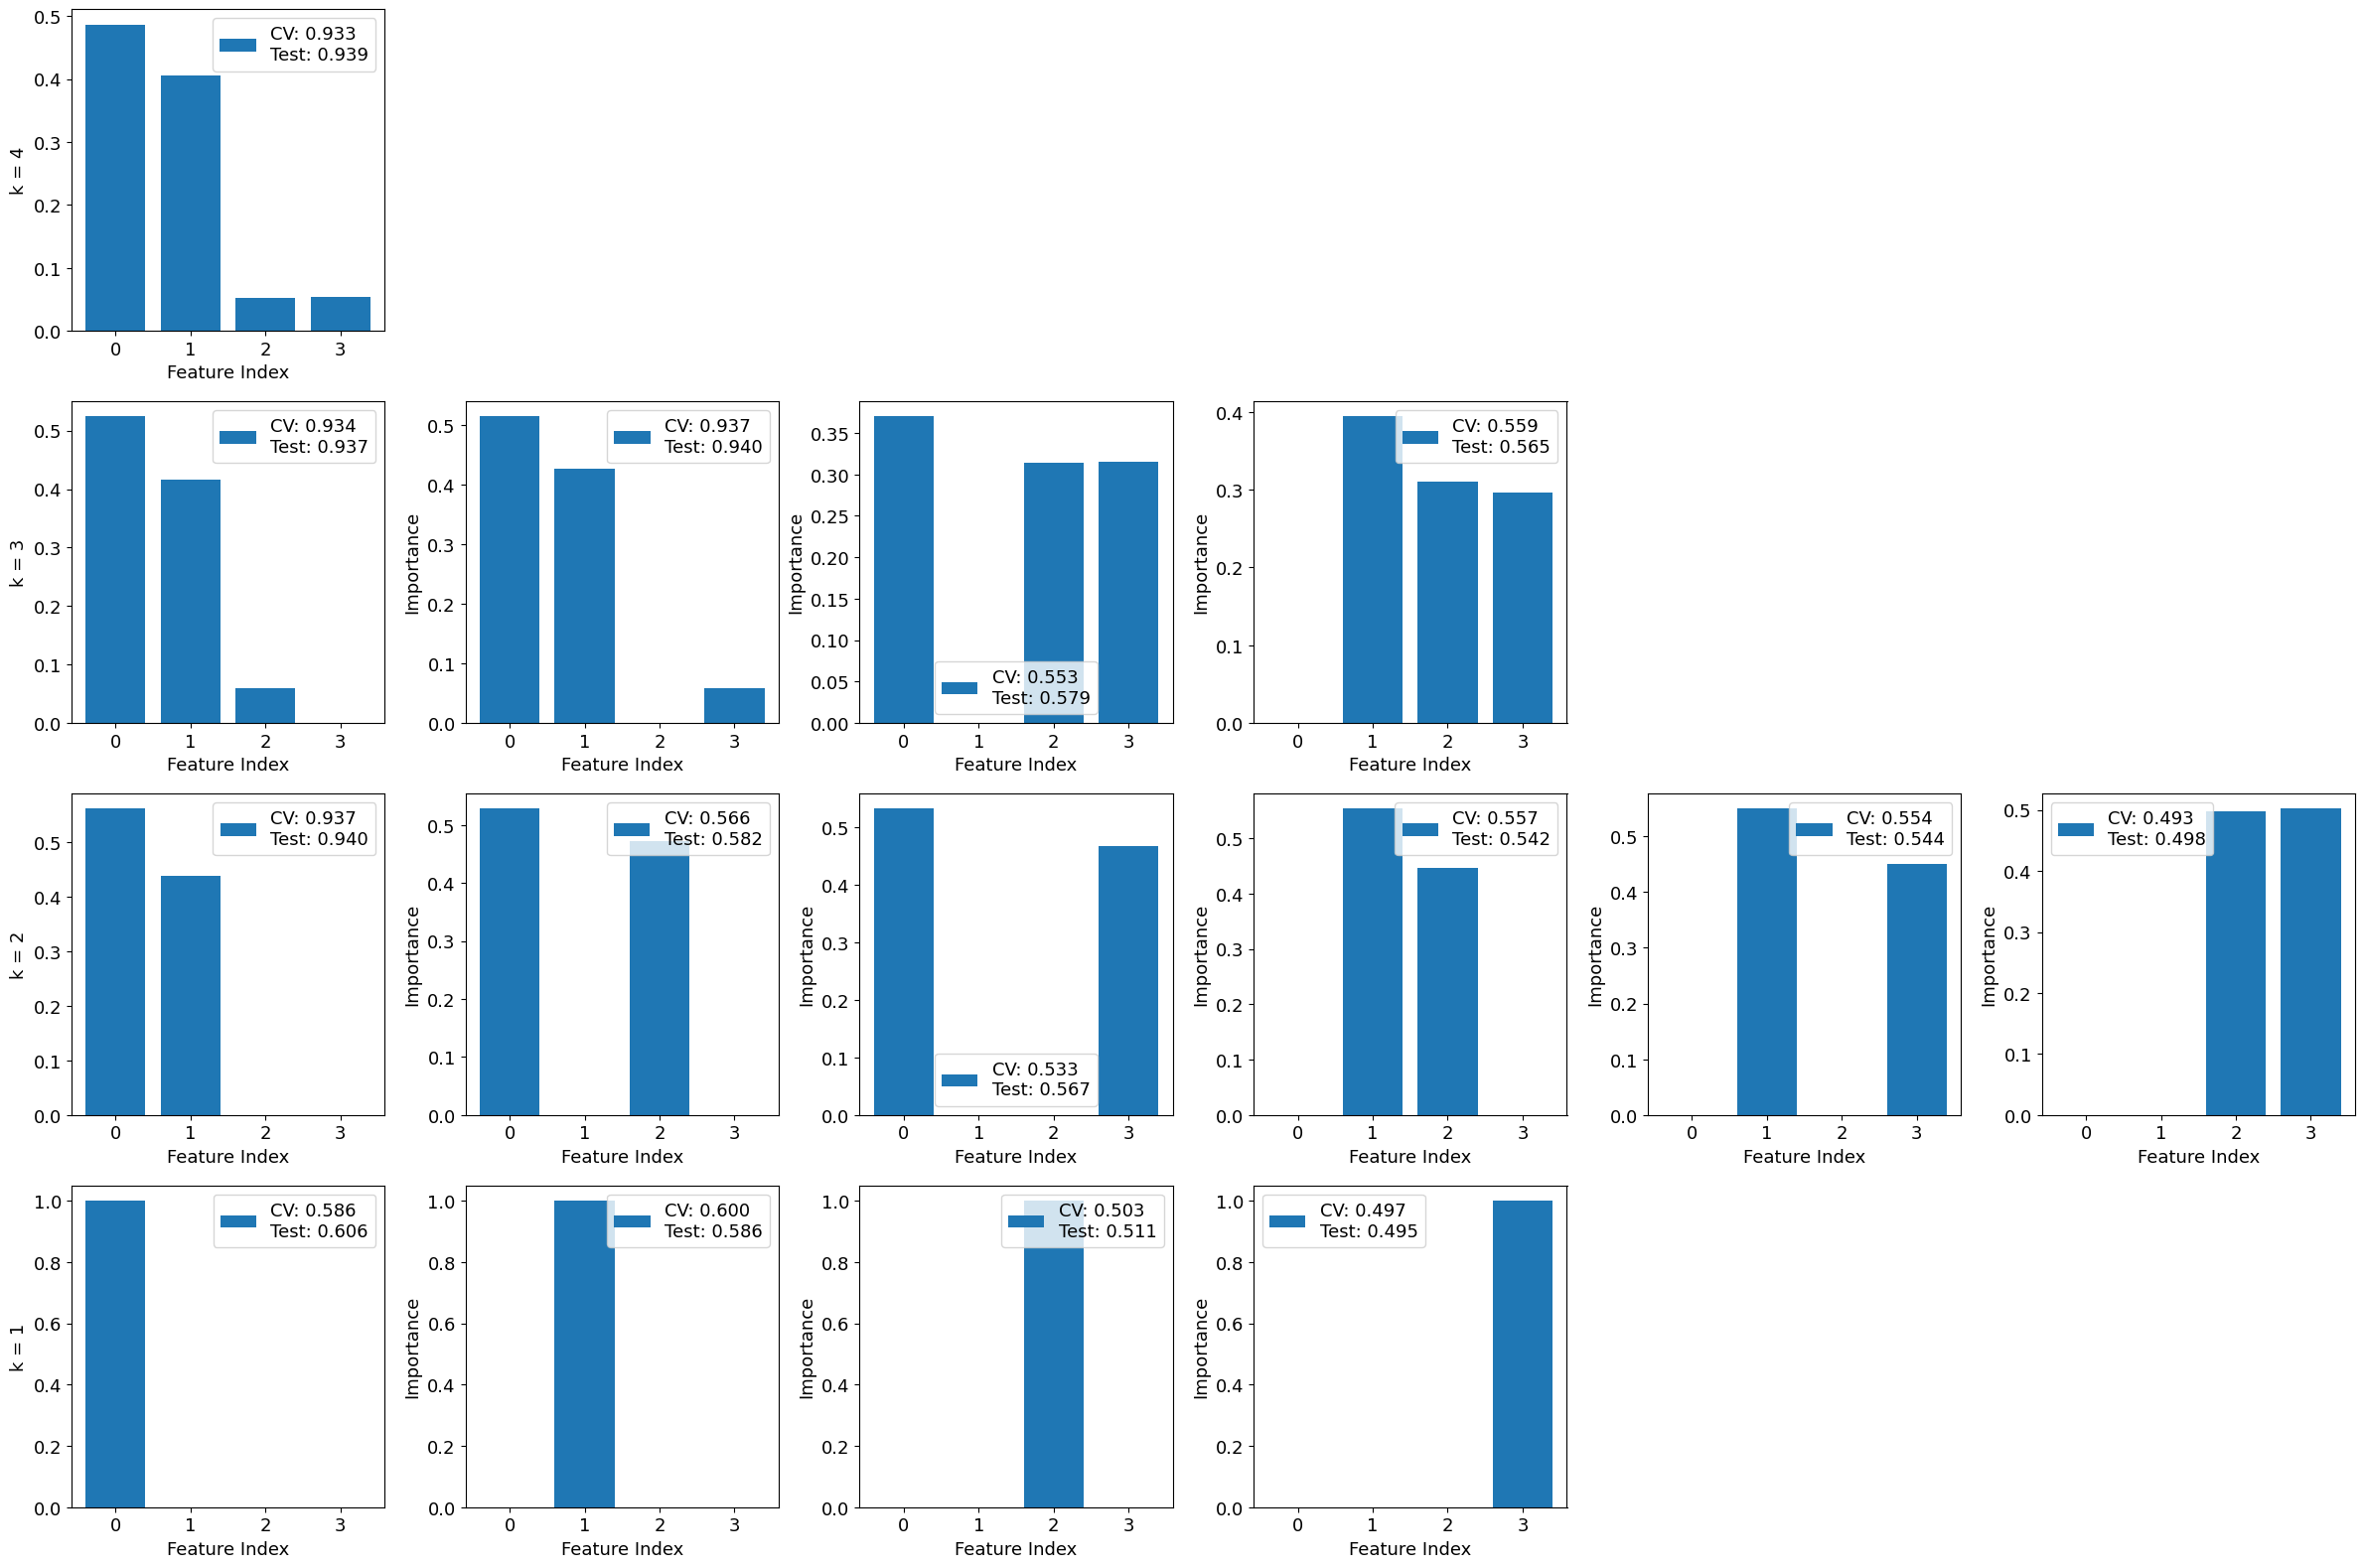

In [ ]:
from sklearn.model_selection import cross_val_score

all_combs = {4: [(0, 1, 2, 3)],
             3: [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)],
             2: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)],
             1: [(0,), (1,), (2,), (3,)]
             }

fig, axes = plt.subplots(4, 6, figsize=(24, 16))

for k in range(4, 0, -1):
    combs = all_combs[k]
    axes[4-k, 0].set_ylabel(f"k = {k}")

    for col_idx in range(6):
        ax = axes[4-k, col_idx]
        
        if col_idx >= len(combs):
            ax.axis("off")
            continue
        
        selected_features = list(combs[col_idx])
        
        x_train_reduced = x_train[:, selected_features]
        x_test_reduced = x_test[:, selected_features]
        
        # Train model
        model = XGBClassifier(seed=1, objective='binary:logistic', **best_params)
        model.fit(x_train_reduced, y_train)
        
        # Metrics
        cv_score = cross_val_score(model, x_train_reduced, y_train, cv=4).mean()
        test_score = model.score(x_test_reduced, y_test)

        # Importances
        importances = model.feature_importances_
        full_importances = np.zeros(4)
        
        for idx, feat in enumerate(selected_features):
            full_importances[feat] = importances[idx]
        
        # Plot
        ax.bar(range(4), full_importances, label=f"CV: {cv_score:.3f}\nTest: {test_score:.3f}")
        
        ax.set_xticks(range(4))
        ax.set_xlabel("Feature Index")
        ax.set_ylabel("Importance")
        ax.legend()
    
plt.tight_layout()
plt.show()

Removing features 2 and 3 leads to slightly better cross validation and test accuracies.

## 3. XGBoost vs NN

Compare the validation accuracy of XGB with that of a simple feed-forward neural network (FFNN)
- By varying the number of data samples N’ in the training set (i.e., reducing the fraction N’/N of the data set used for training)
- With cross-validation for all cases.
Is the FFNN or the XGB performing significantly better at low N’?



c:\Users\dev\Desktop\lcpb\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fraction 1.0: XGB CV Acc = 0.9339, FFNN CV Acc = 0.8371


c:\Users\dev\Desktop\lcpb\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fraction 0.75: XGB CV Acc = 0.9097, FFNN CV Acc = 0.7507


c:\Users\dev\Desktop\lcpb\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fraction 0.5: XGB CV Acc = 0.8976, FFNN CV Acc = 0.6112


c:\Users\dev\Desktop\lcpb\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fraction 0.25: XGB CV Acc = 0.8143, FFNN CV Acc = 0.5752


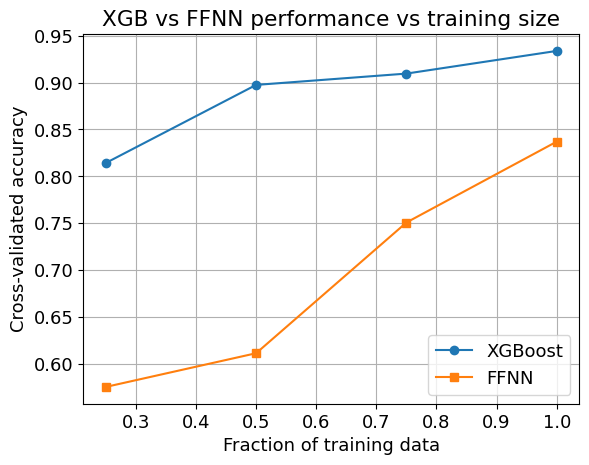

In [ ]:
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential
from keras.layers import Dense, Dropout

def create_ffnn(input_dim):
    model = Sequential()
    model.add(Dense(64, input_dim=input_dim, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid')) # sigmoid for binary classification
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def ffnn_cv_accuracy(X, y):
    skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        model = create_ffnn(input_dim=X.shape[1])
        model.fit(X_train_fold, y_train_fold, epochs=400, verbose=0)
        
        # Evaluate on validation fold
        accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)[1] # [1] is accuracy
        scores.append(accuracy)
    
    return np.mean(scores)

fractions = [1.0, 0.75, 0.5, 0.25]
xgb_scores = []
ffnn_scores = []
for frac in fractions:
    # Reduce training set
    N = x_train.shape[0]
    idx = np.random.choice(N, int(N*frac), replace=False)
    X_reduced = x_train[idx]
    y_reduced = y_train[idx]

    # XGBoost
    xgb_model = XGBClassifier(seed=1, objective='binary:logistic', **best_params)
    xgb_score = np.mean(cross_val_score(xgb_model, X_reduced, y_reduced, cv=4, scoring='accuracy'))
    xgb_scores.append(xgb_score)

    # FFNN
    ffnn_score = ffnn_cv_accuracy(X_reduced, y_reduced)
    ffnn_scores.append(ffnn_score)

    print(f"Fraction {frac}: XGB CV Acc = {xgb_score:.4f}, FFNN CV Acc = {ffnn_score:.4f}")



plt.figure()
plt.plot(fractions, xgb_scores, marker='o', label='XGBoost')
plt.plot(fractions, ffnn_scores, marker='s', label='FFNN')
plt.xlabel("Fraction of training data")
plt.ylabel("Cross-validated accuracy")
plt.title("XGB vs FFNN performance vs training size")
plt.legend()
plt.grid(True)
plt.show()

For this learning problem XGBoost performs significantly better than the FFNN , especially for smaller fractions of training data. It is also computationally faster. The FFNN does not perform better with smaller architectures, nor with other slighly larger, 3-layers architectures.